In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install wandb torch torchvision pandas numpy matplotlib seaborn scikit-learn mlflow
!pip install kaggle

In [ ]:
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/cs231n/assignments/4/kaggle.json ~/.kaggle/kaggle.json
! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle competitions download -c walmart-recruiting-store-sales-forecasting
!unzip -q walmart-recruiting-store-sales-forecasting.zip

100% 2.70M/2.70M [00:00<00:00, 187MB/s]



In [ ]:
!unzip -q train.csv.zip
!unzip -q stores.csv.zip
!unzip -q test.csv.zip
!unzip -q features.csv.zip

replace train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
unzip:  cannot find or open stores.csv.zip, stores.csv.zip.zip or stores.csv.zip.ZIP.
replace features.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime, timedelta
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
import scipy.stats as stats

warnings.filterwarnings('ignore')

In [ ]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
stores = pd.read_csv('stores.csv')
features = pd.read_csv('features.csv')

In [ ]:
for name, df in {
    'train': train,
    'test': test,
    'stores': stores,
    'features': features
}.items():
    print(f"\n{name}")
    print(df.shape)
    print(df.info())


train
(421570, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB
None

test
(115064, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115064 entries, 0 to 115063
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Store      115064 non-null  int64 
 1   Dept       115064 non-null  int64 
 2   Date       115064 non-null  object
 3   IsHoliday  115064 non-null  bool  
dtypes: bool(1), int64(2), object(1)
memory usage: 2.7+ MB
None

stores
(45, 3)
<class 'pandas.core.frame.DataFrame'>


In [ ]:
train_full = train.merge(stores, on='Store', how='left')

train_full = train_full.merge(
    features,
    on=['Store', 'Date', 'IsHoliday'],
    how='left'
)

train_full['Date'] = pd.to_datetime(train_full['Date'])

train_full['Year'] = train_full['Date'].dt.year
train_full['Month'] = train_full['Date'].dt.month
train_full['Week'] = train_full['Date'].dt.isocalendar().week

In [ ]:
from sklearn.model_selection import train_test_split

X = train_full.drop('Weekly_Sales', axis=1)
y = train_full['Weekly_Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(337256, 18)
(84314, 18)


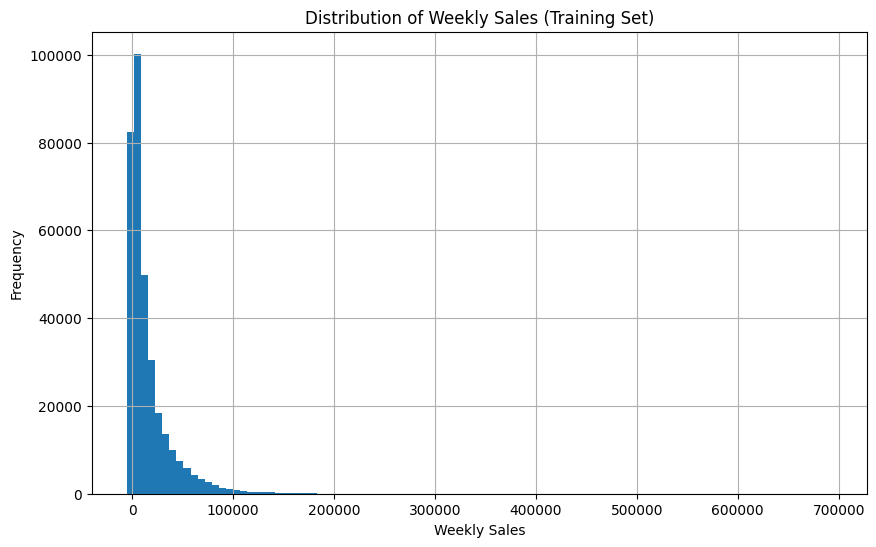

In [ ]:
plt.figure(figsize=(10,6))
y_train.hist(bins=100)

plt.title('Distribution of Weekly Sales (Training Set)')
plt.xlabel('Weekly Sales')
plt.ylabel('Frequency')

plt.show()

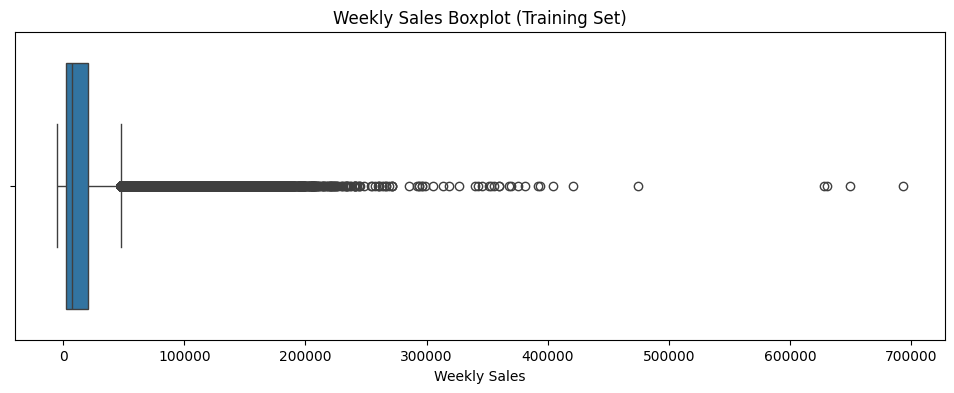

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
sns.boxplot(x=y_train)

plt.title('Weekly Sales Boxplot (Training Set)')
plt.xlabel('Weekly Sales')

plt.show()

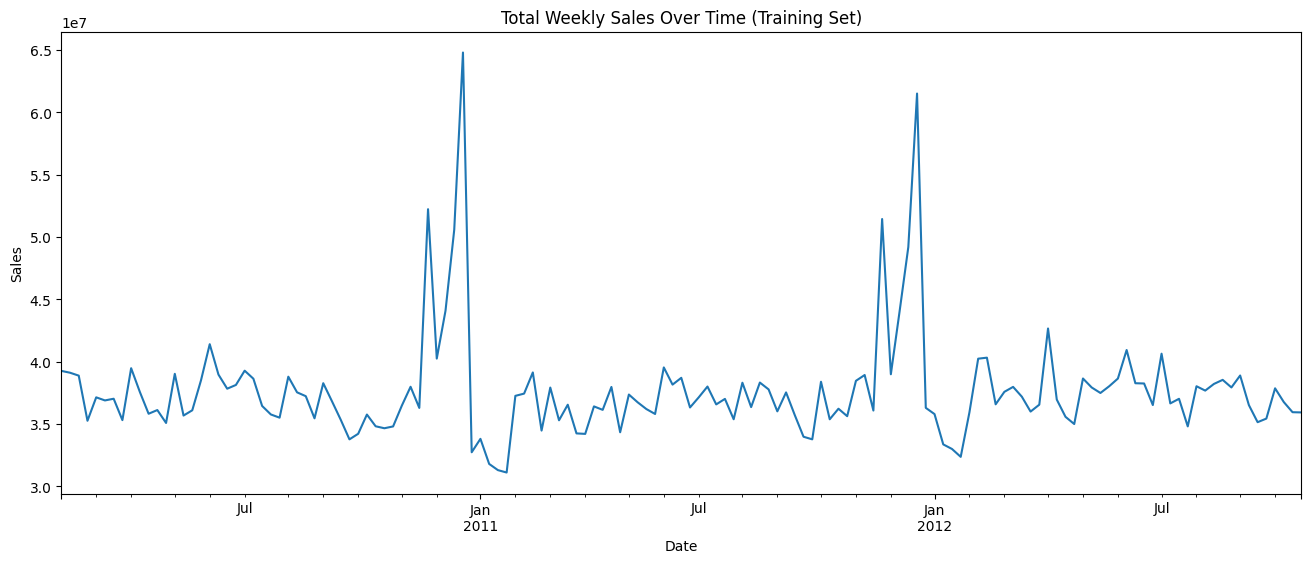

In [ ]:
sales_over_time = pd.concat(
    [X_train['Date'], y_train],
    axis=1
)

sales_over_time = (
    sales_over_time
    .groupby('Date')['Weekly_Sales']
    .sum()
)

plt.figure(figsize=(16,6))
sales_over_time.plot()

plt.title('Total Weekly Sales Over Time (Training Set)')
plt.ylabel('Sales')

plt.show()

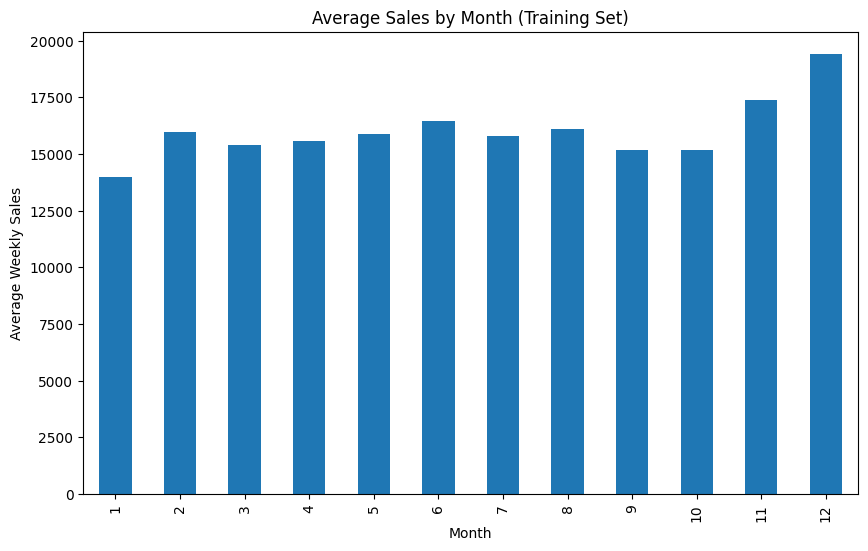

In [ ]:
train_plot = X_train.copy()
train_plot['Weekly_Sales'] = y_train

monthly = (
    train_plot
    .groupby('Month')['Weekly_Sales']
    .mean()
)

plt.figure(figsize=(10,6))
monthly.plot(kind='bar')

plt.title('Average Sales by Month (Training Set)')
plt.xlabel('Month')
plt.ylabel('Average Weekly Sales')

plt.show()

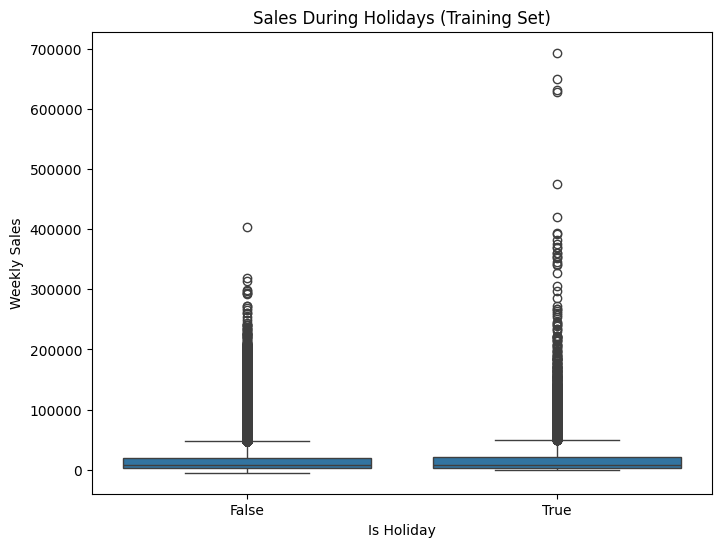

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

train_plot = X_train.copy()
train_plot['Weekly_Sales'] = y_train

plt.figure(figsize=(8,6))
sns.boxplot(
    data=train_plot,
    x='IsHoliday',
    y='Weekly_Sales'
)

plt.title('Sales During Holidays (Training Set)')
plt.xlabel('Is Holiday')
plt.ylabel('Weekly Sales')

plt.show()

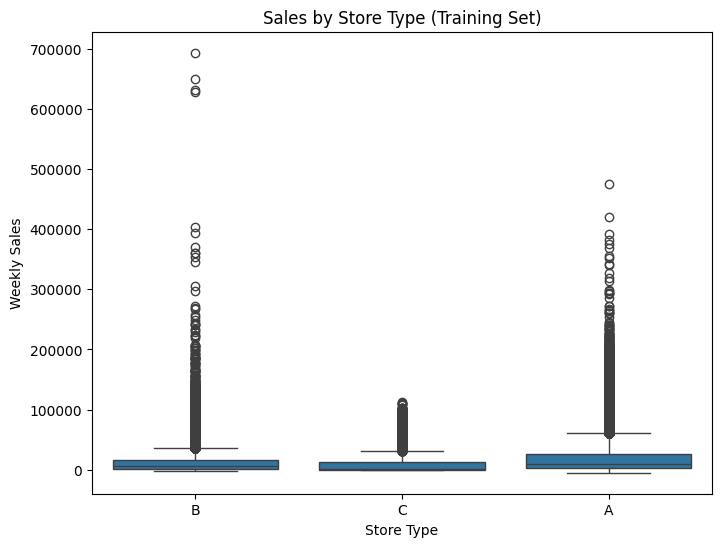

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

train_plot = X_train.copy()
train_plot['Weekly_Sales'] = y_train

plt.figure(figsize=(8,6))
sns.boxplot(
    data=train_plot,
    x='Type',
    y='Weekly_Sales'
)

plt.title('Sales by Store Type (Training Set)')
plt.xlabel('Store Type')
plt.ylabel('Weekly Sales')

plt.show()

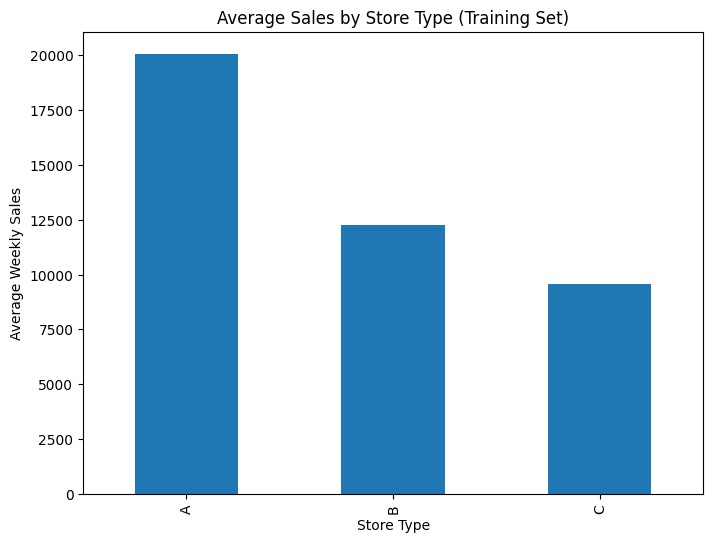

In [ ]:
train_plot = X_train.copy()
train_plot['Weekly_Sales'] = y_train

type_sales = (
    train_plot
    .groupby('Type')['Weekly_Sales']
    .mean()
)

plt.figure(figsize=(8,6))
type_sales.plot(kind='bar')

plt.title('Average Sales by Store Type (Training Set)')
plt.xlabel('Store Type')
plt.ylabel('Average Weekly Sales')

plt.show()

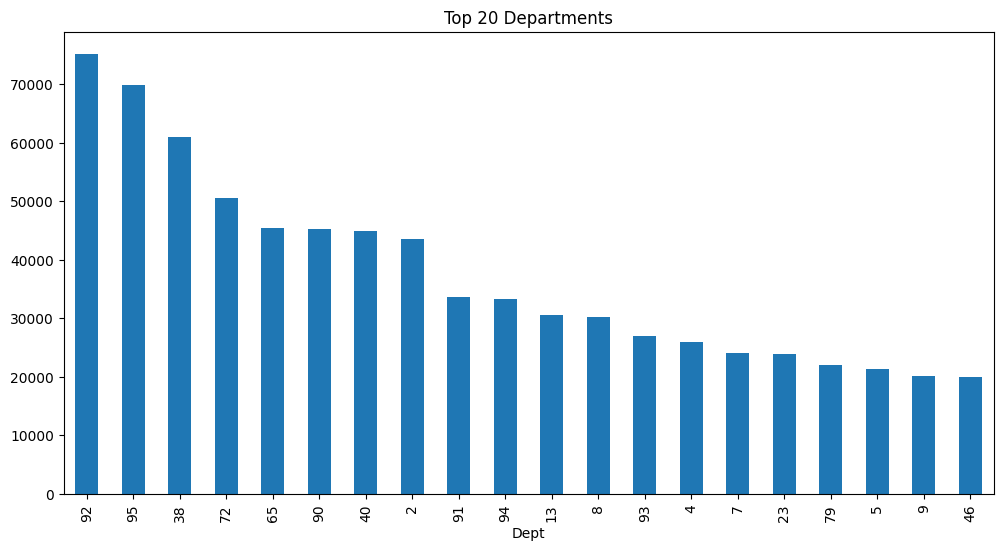

In [ ]:
dept_sales = (
    train_full.groupby('Dept')['Weekly_Sales']
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,6))
dept_sales.plot(kind='bar')
plt.title('Top 20 Departments')
plt.show()

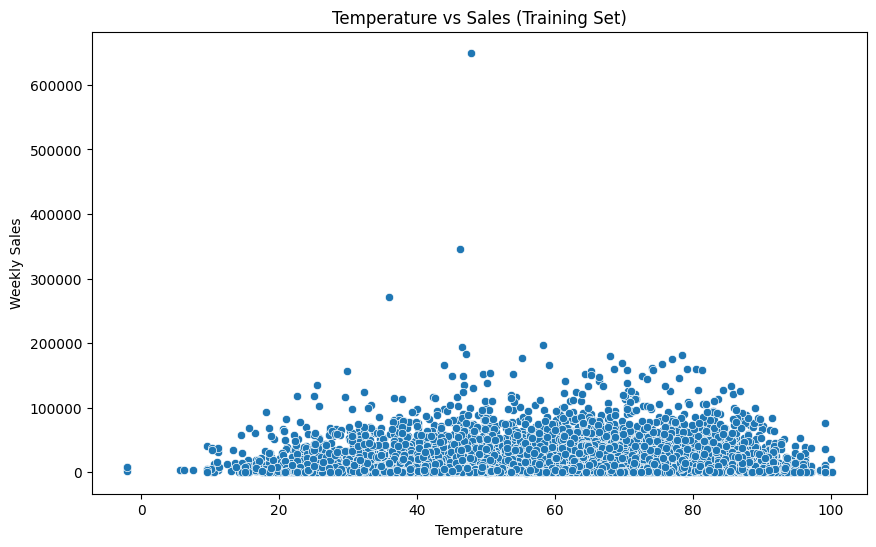

In [ ]:
train_plot = X_train.copy()
train_plot['Weekly_Sales'] = y_train

sample = train_plot.sample(
    min(10000, len(train_plot)),
    random_state=42
)

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=sample,
    x='Temperature',
    y='Weekly_Sales'
)

plt.title('Temperature vs Sales (Training Set)')
plt.xlabel('Temperature')
plt.ylabel('Weekly Sales')

plt.show()

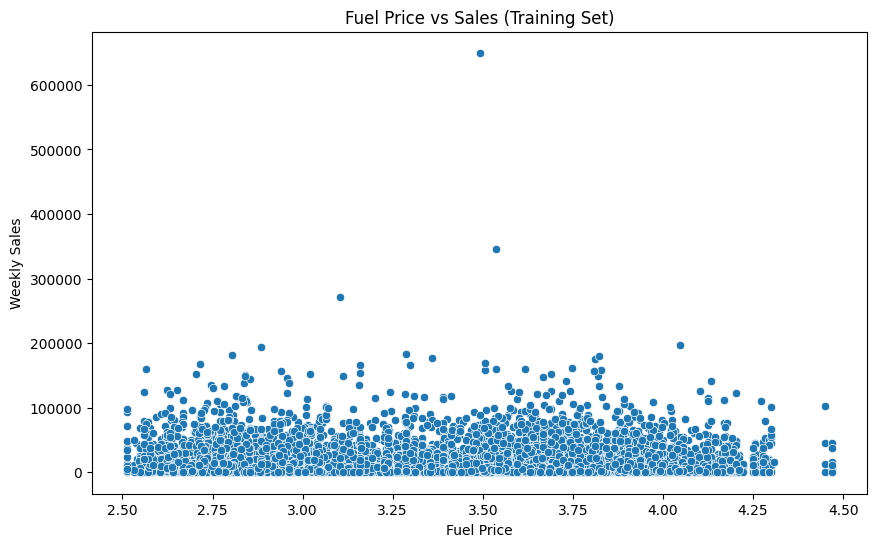

In [ ]:
train_plot = X_train.copy()
train_plot['Weekly_Sales'] = y_train

sample = train_plot.sample(
    min(10000, len(train_plot)),
    random_state=42
)

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=sample,
    x='Fuel_Price',
    y='Weekly_Sales'
)

plt.title('Fuel Price vs Sales (Training Set)')
plt.xlabel('Fuel Price')
plt.ylabel('Weekly Sales')

plt.show()

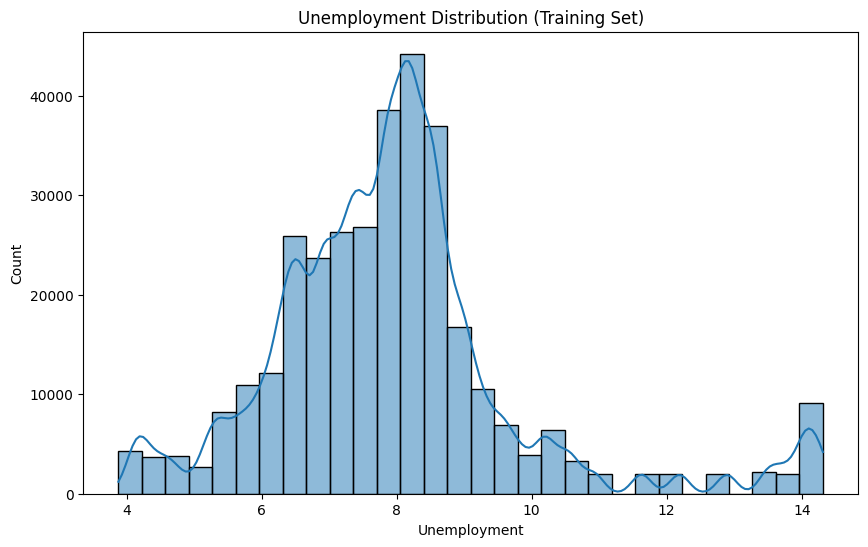

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.histplot(
    X_train['Unemployment'],
    bins=30,
    kde=True
)

plt.title('Unemployment Distribution (Training Set)')
plt.xlabel('Unemployment')
plt.ylabel('Count')

plt.show()

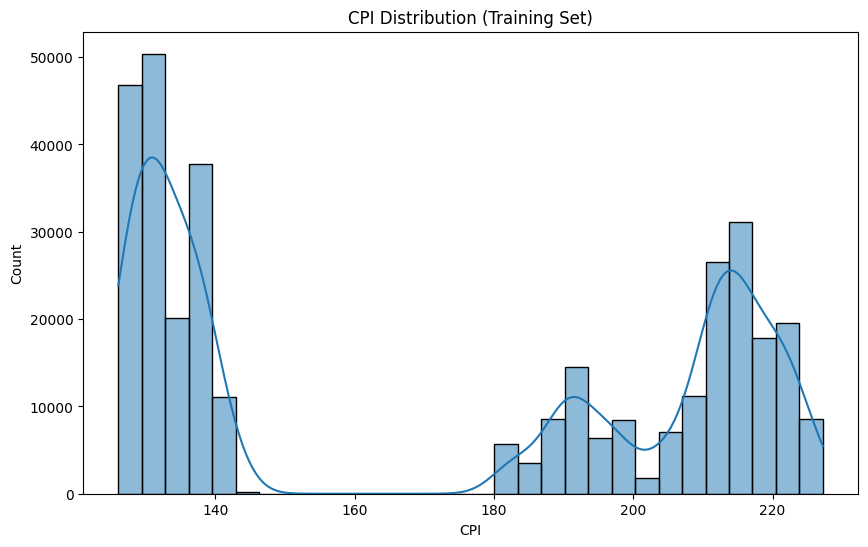

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(
    X_train['CPI'],
    bins=30,
    kde=True
)

plt.title('CPI Distribution (Training Set)')
plt.xlabel('CPI')
plt.ylabel('Count')

plt.show()

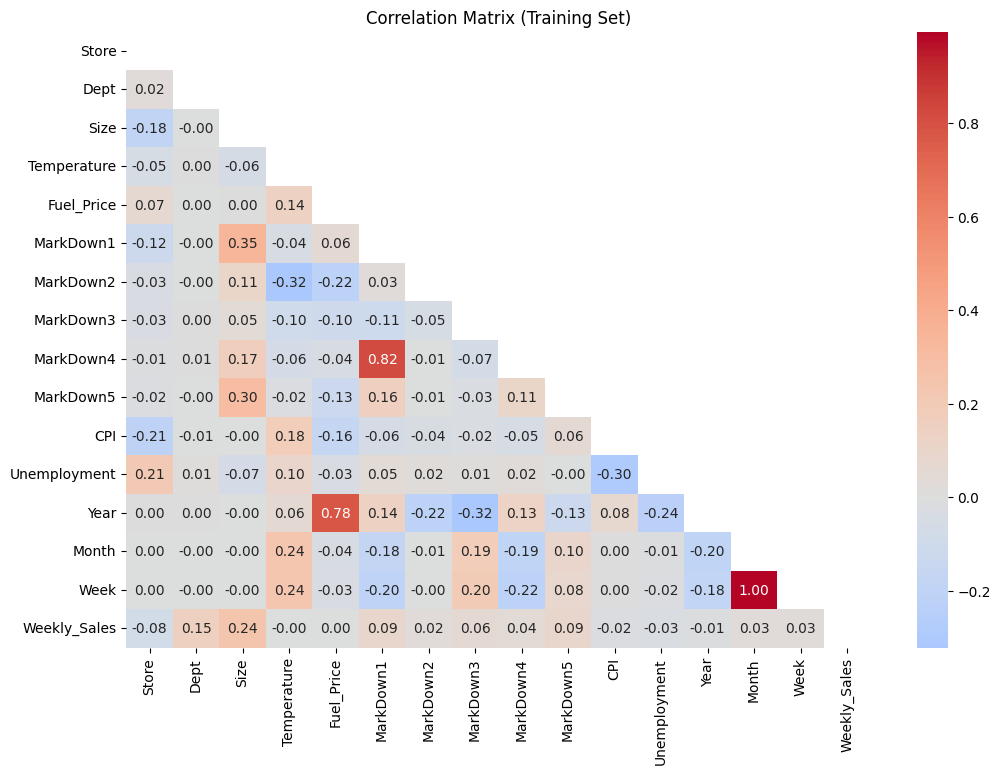

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

train_corr = X_train.copy()
train_corr['Weekly_Sales'] = y_train

numeric_cols = train_corr.select_dtypes(include=['number'])

corr = numeric_cols.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12,8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix (Training Set)')
plt.show()

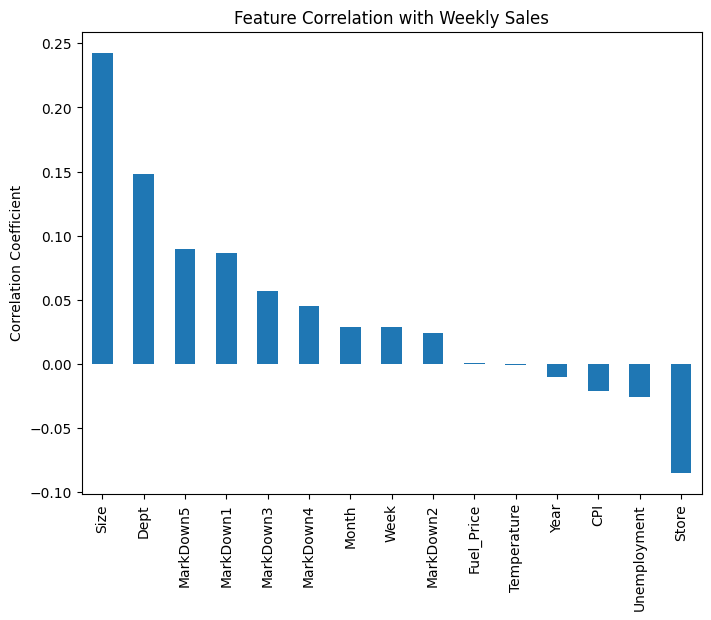

In [ ]:
target_corr = (
    corr['Weekly_Sales']
    .drop('Weekly_Sales')
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,6))
target_corr.plot(kind='bar')

plt.title('Feature Correlation with Weekly Sales')
plt.ylabel('Correlation Coefficient')

plt.show()

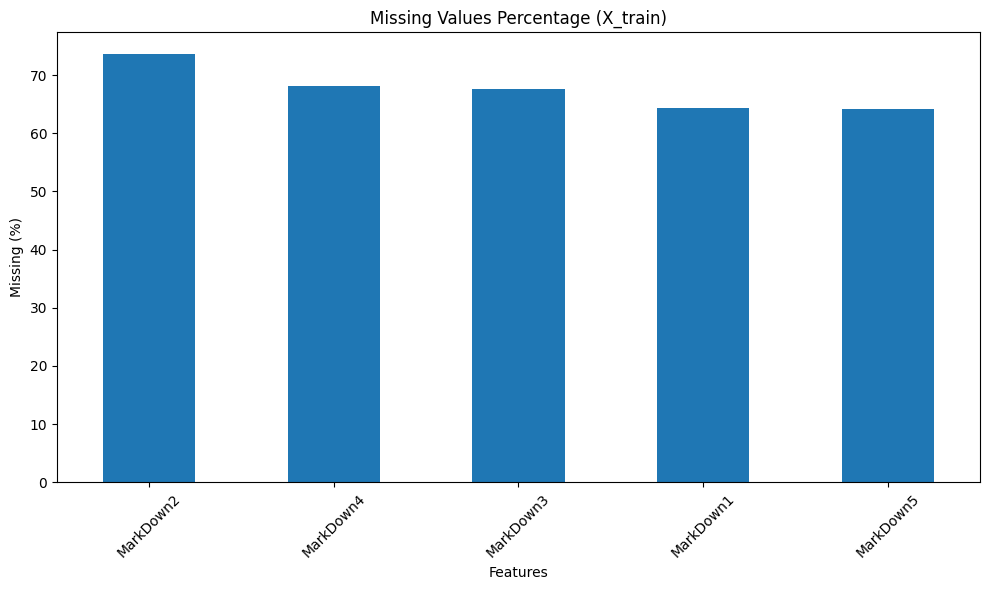

In [ ]:
import matplotlib.pyplot as plt

# calculate missing %
missing_pct = (
    X_train.isnull().mean() * 100
).sort_values(ascending=False)

# keep only columns with missing values
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(10,6))
missing_pct.plot(kind='bar')

plt.title('Missing Values Percentage (X_train)')
plt.ylabel('Missing (%)')
plt.xlabel('Features')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

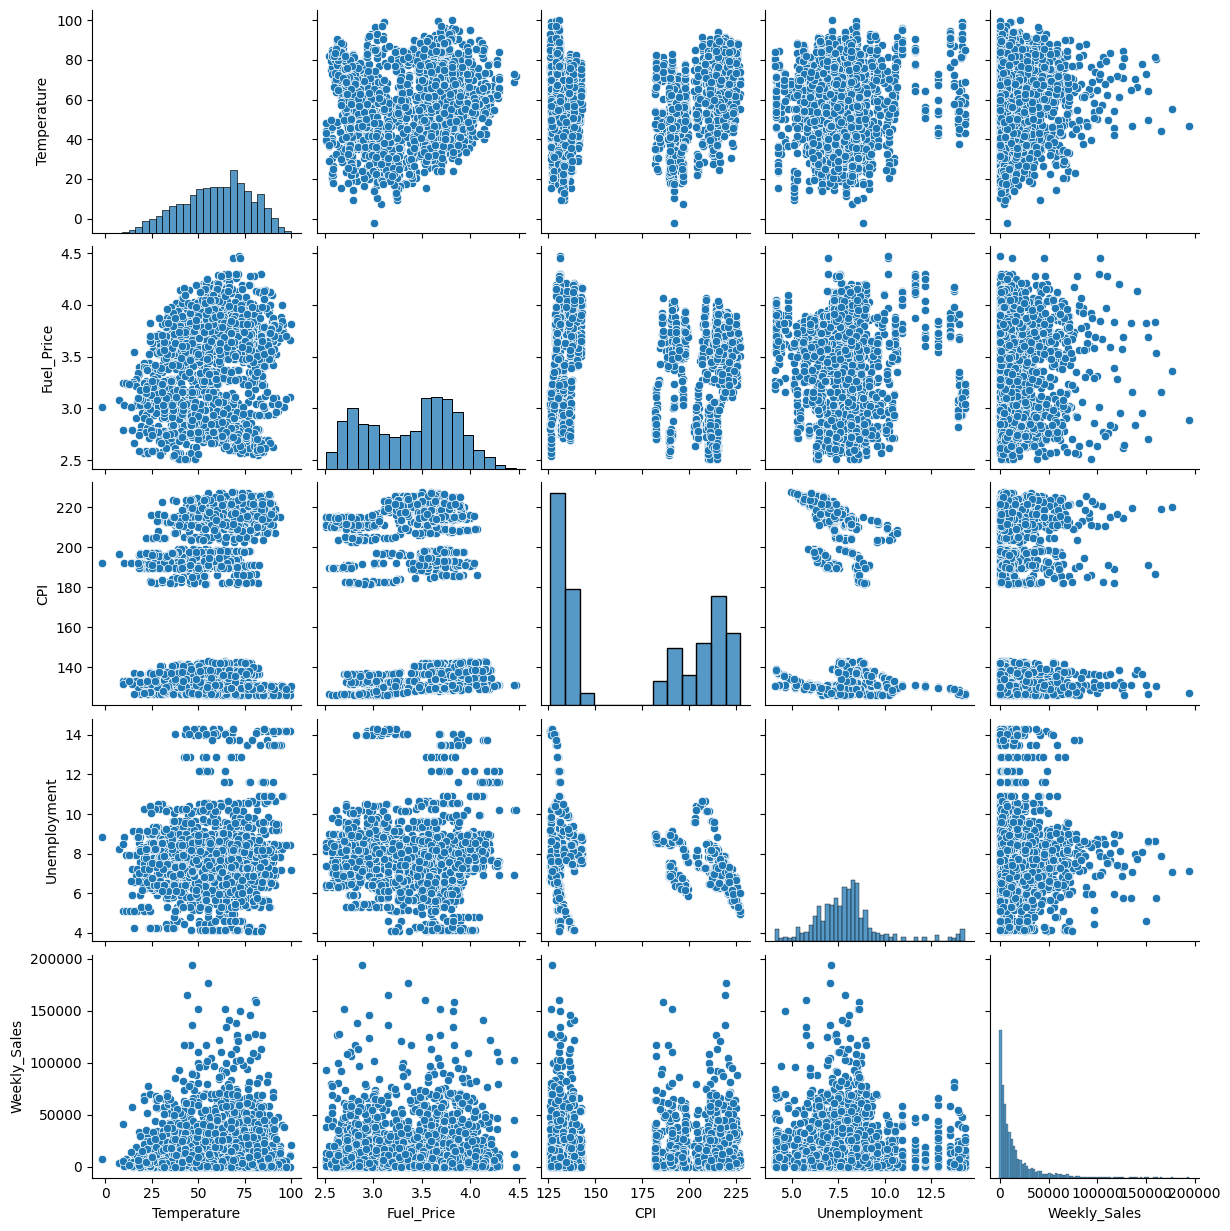

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = [
    'Temperature',
    'Fuel_Price',
    'CPI',
    'Unemployment'
]

# combine features + target safely
plot_data = X_train[cols].copy()
plot_data['Weekly_Sales'] = y_train

# sample for speed
sample = plot_data.sample(
    min(3000, len(plot_data)),
    random_state=42
)

sns.pairplot(sample)
plt.show()

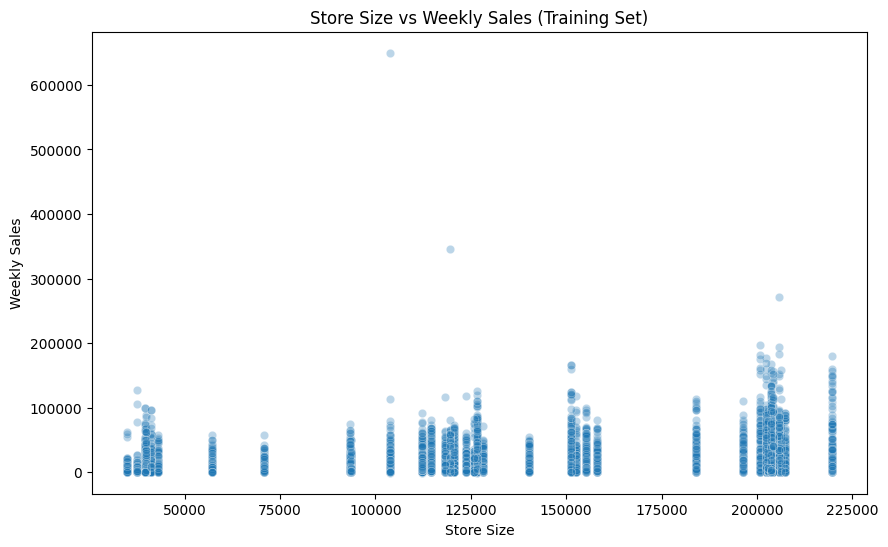

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

train_plot = X_train.copy()
train_plot['Weekly_Sales'] = y_train

sample = train_plot.sample(
    min(10000, len(train_plot)),
    random_state=42
)

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=sample,
    x='Size',
    y='Weekly_Sales',
    alpha=0.3
)

plt.title('Store Size vs Weekly Sales (Training Set)')
plt.xlabel('Store Size')
plt.ylabel('Weekly Sales')

plt.show()

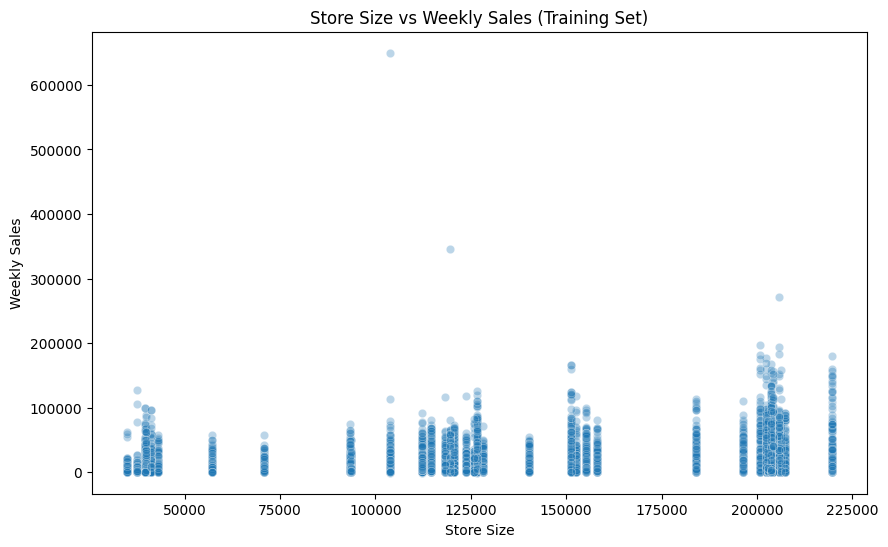

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# combine safely
train_plot = X_train.copy()
train_plot['Weekly_Sales'] = y_train

# sample for speed
sample = train_plot.sample(
    min(10000, len(train_plot)),
    random_state=42
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample,
    x='Size',
    y='Weekly_Sales',
    alpha=0.3
)

plt.title('Store Size vs Weekly Sales (Training Set)')
plt.xlabel('Store Size')
plt.ylabel('Weekly Sales')

plt.show()

In [ ]:
X_train.head()

,Store,Dept,Date,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Week
138466,15,3,2011-04-01,False,B,123737,30.34,3.811,NaN,NaN,NaN,NaN,NaN,134.068258,7.658,2011,4,13
289214,30,25,2010-06-11,False,C,42988,83.51,2.668,NaN,NaN,NaN,NaN,NaN,211.112002,8.200,2010,6,23
52351,6,27,2010-06-04,False,A,202505,79.44,2.705,NaN,NaN,NaN,NaN,NaN,212.698244,7.092,2010,6,22
203504,21,49,2011-12-02,False,B,140167,48.72,3.172,3389.10,43.0,1258.32,325.35,8623.67,218.359032,7.441,2011,12,48
233606,24,55,2012-01-06,False,A,203819,32.86,3.585,7325.68,25367.9,203.51,1745.20,3261.35,136.698129,8.659,2012,1,1


In [ ]:
y_train.head()

,Weekly_Sales
138466,7490.24
289214,48.25
52351,1262.75
203504,8722.34
233606,15247.36


In [ ]:
missing_cols = X_train.columns[X_train.isnull().any()]

In [ ]:
stats = []

for col in missing_cols:
    stats.append({
        "column": col,
        "mean": X_train[col].mean(),
        "min": X_train[col].min(),
        "max": X_train[col].max(),
        "mode": X_train[col].mode()[0] if not X_train[col].mode().empty else None,
        "missing_%": X_train[col].isnull().mean() * 100
    })

stats_df = pd.DataFrame(stats)

stats_df

,column,mean,min,max,mode,missing_%
0,MarkDown1,7246.072689,0.27,88646.76,460.73,64.343407
1,MarkDown2,3326.104444,-265.76,104519.54,1.91,73.667185
2,MarkDown3,1427.455081,-29.10,141630.61,3.00,67.540385
3,MarkDown4,3379.433667,0.22,67474.85,9.00,68.063133
4,MarkDown5,4637.087319,135.16,108519.28,2743.18,64.161942


In [ ]:
stats_df.sort_values("missing_%", ascending=False)

,column,mean,min,max,mode,missing_%
1,MarkDown2,3326.104444,-265.76,104519.54,1.91,73.667185
3,MarkDown4,3379.433667,0.22,67474.85,9.00,68.063133
2,MarkDown3,1427.455081,-29.10,141630.61,3.00,67.540385
0,MarkDown1,7246.072689,0.27,88646.76,460.73,64.343407
4,MarkDown5,4637.087319,135.16,108519.28,2743.18,64.161942
